In [3]:
# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import library scikit-learn untuk clustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Setting tampilan
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


In [4]:
# Load dataset (gunakan sampling untuk efisiensi)
df_full = pd.read_csv('data.csv')

# Ambil sampel 50.000 baris untuk praktikum
np.random.seed(42)
df = df_full.sample(n=50000, random_state=42).reset_index(drop=True)

print("Ukuran dataset lengkap:", df_full.shape)
print("Ukuran dataset sampel:", df.shape)
print("\n5 Baris Pertama:")
df.head()

Ukuran dataset lengkap: (98000, 30)
Ukuran dataset sampel: (50000, 30)

5 Baris Pertama:


,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,f_09,f_10,f_11,f_12,f_13,f_14,f_15,f_16,f_17,f_18,f_19,f_20,f_21,f_22,f_23,f_24,f_25,f_26,f_27,f_28
0,41816,-0.421934,0.948380,0.623958,-0.150342,1.121531,-0.353781,0.221547,4,16,6,11,11,7,3,0.013778,-0.580694,0.966539,-0.013128,0.877747,-0.626830,-0.386469,1.039863,-0.355335,-0.498830,-0.453695,0.074344,-0.132835,-0.314319,1.648563
1,90575,-0.409700,-1.198915,0.258000,0.410483,-0.619851,0.217080,0.759006,6,9,6,6,9,0,10,-0.244763,0.212334,-0.818425,1.138385,-0.388450,-0.319935,0.615553,-0.251309,-0.115564,-0.544548,0.854086,-3.569491,-2.617825,-2.055976,-1.424825
2,15056,-0.925194,1.426141,0.563657,-0.501369,1.712945,0.175180,-0.565831,8,7,17,11,9,5,4,0.794788,-0.891853,-0.773476,0.253268,0.009393,0.322724,-0.634064,-0.844679,-0.302786,-0.522947,1.001543,0.525206,1.375116,-0.615967,-1.187483
3,32565,-1.505368,0.553782,-0.033451,1.322642,-0.398403,0.055724,1.026911,3,11,0,11,7,7,6,0.658157,2.288540,0.618358,1.131560,0.513452,0.311159,0.538255,0.812111,2.154462,1.158176,1.355220,-1.192539,-0.025902,2.506592,0.059270
4,24138,-0.711784,-0.625115,-1.146813,0.292551,0.375784,0.338374,0.139842,2,1,20,16,2,4,3,1.549985,-2.292495,-0.789518,0.497212,-0.329388,0.120524,-0.536504,0.278953,-1.461591,1.682080,-0.289337,-0.710302,1.413688,0.213328,-0.545192


In [5]:
# Informasi tipe data
print("Informasi Dataset:")
df.info()

# Statistik deskriptif
print("\nStatistik Deskriptif:")
df.describe()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      50000 non-null  int64  
 1   f_00    50000 non-null  float64
 2   f_01    50000 non-null  float64
 3   f_02    50000 non-null  float64
 4   f_03    50000 non-null  float64
 5   f_04    50000 non-null  float64
 6   f_05    50000 non-null  float64
 7   f_06    50000 non-null  float64
 8   f_07    50000 non-null  int64  
 9   f_08    50000 non-null  int64  
 10  f_09    50000 non-null  int64  
 11  f_10    50000 non-null  int64  
 12  f_11    50000 non-null  int64  
 13  f_12    50000 non-null  int64  
 14  f_13    50000 non-null  int64  
 15  f_14    50000 non-null  float64
 16  f_15    50000 non-null  float64
 17  f_16    50000 non-null  float64
 18  f_17    50000 non-null  float64
 19  f_18    50000 non-null  float64
 20  f_19    50000 non-null  float64
 21  f_20    50000 no

,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,f_09,f_10,f_11,f_12,f_13,f_14,f_15,f_16,f_17,f_18,f_19,f_20,f_21,f_22,f_23,f_24,f_25,f_26,f_27,f_28
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,49051.507780,-0.000883,0.002629,0.003750,-0.003529,-0.006189,-0.003638,-0.003061,5.534180,6.763660,8.171240,8.045720,8.112700,7.08036,6.287600,0.000196,-0.006560,0.013640,0.002995,-0.003962,-0.001582,0.002575,-0.001969,-0.039459,-0.228159,0.162413,-0.067440,-0.064704,0.100463,-0.232220
std,28191.757751,1.003434,0.998856,1.003348,1.000620,1.001908,1.000783,0.994348,3.686389,4.155304,5.903708,4.710732,4.208277,4.41213,4.132949,1.000696,1.001325,1.001806,0.999980,0.998341,1.001885,1.002178,1.003771,1.478529,1.492995,1.541334,1.576114,1.422470,1.308211,1.532116
min,0.000000,-4.224963,-3.796602,-4.377021,-3.971421,-4.535903,-3.927592,-4.051634,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,-4.377021,-3.692710,-4.182233,-4.202795,-3.998074,-4.174151,-4.732235,-4.438130,-6.873999,-7.463248,-6.553458,-6.593842,-7.016655,-7.335556,-6.954151
25%,24847.750000,-0.678221,-0.675965,-0.668326,-0.672446,-0.684175,-0.678993,-0.676676,3.000000,4.000000,4.000000,5.000000,5.000000,4.00000,3.000000,-0.677271,-0.685727,-0.661805,-0.674772,-0.683154,-0.670655,-0.674930,-0.674966,-1.028943,-1.218259,-0.908796,-1.132605,-0.978047,-0.750603,-1.264023
50%,48940.000000,0.001034,0.005383,0.003450,-0.006639,-0.007511,0.002427,-0.000559,5.000000,6.000000,7.000000,7.000000,8.000000,6.50000,6.000000,-0.001130,-0.005004,0.013823,0.003124,0.002374,-0.000180,0.000960,-0.001713,-0.051828,-0.232640,0.166195,-0.096598,-0.073956,0.086337,-0.276803
75%,73394.250000,0.676225,0.676552,0.682313,0.666004,0.677715,0.673635,0.671349,8.000000,9.000000,11.000000,11.000000,11.000000,10.00000,9.000000,0.675813,0.664524,0.690953,0.675320,0.673539,0.674589,0.678349,0.673656,0.926767,0.750727,1.213833,0.985148,0.843610,0.933900,0.762258
max,97999.000000,3.912149,4.324974,4.560247,4.399373,4.033918,4.710316,3.748715,32.000000,26.000000,44.000000,36.000000,28.000000,37.00000,30.000000,4.490521,4.270708,4.018127,3.966532,4.237148,4.560247,4.324974,4.135419,6.450214,5.887920,7.527271,7.086851,7.005608,6.725752,6.470349


In [6]:
# Cek missing value
print("Jumlah Missing Value per Kolom:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])

# Cek duplikat
print(f"\nJumlah Data Duplikat: {df.duplicated().sum()}")

Jumlah Missing Value per Kolom:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Jumlah Data Duplikat: 0


In [7]:
# Pisahkan kolom numerik dan kategorikal
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Jumlah kolom numerik: {len(numerical_cols)}")
print(f"Jumlah kolom kategorikal: {len(categorical_cols)}")
print(f"\nKolom numerik: {numerical_cols[:10]}...")
print(f"\nKolom kategorikal: {categorical_cols}")

Jumlah kolom numerik: 30
Jumlah kolom kategorikal: 0

Kolom numerik: ['id', 'f_00', 'f_01', 'f_02', 'f_03', 'f_04', 'f_05', 'f_06', 'f_07', 'f_08']...

Kolom kategorikal: []


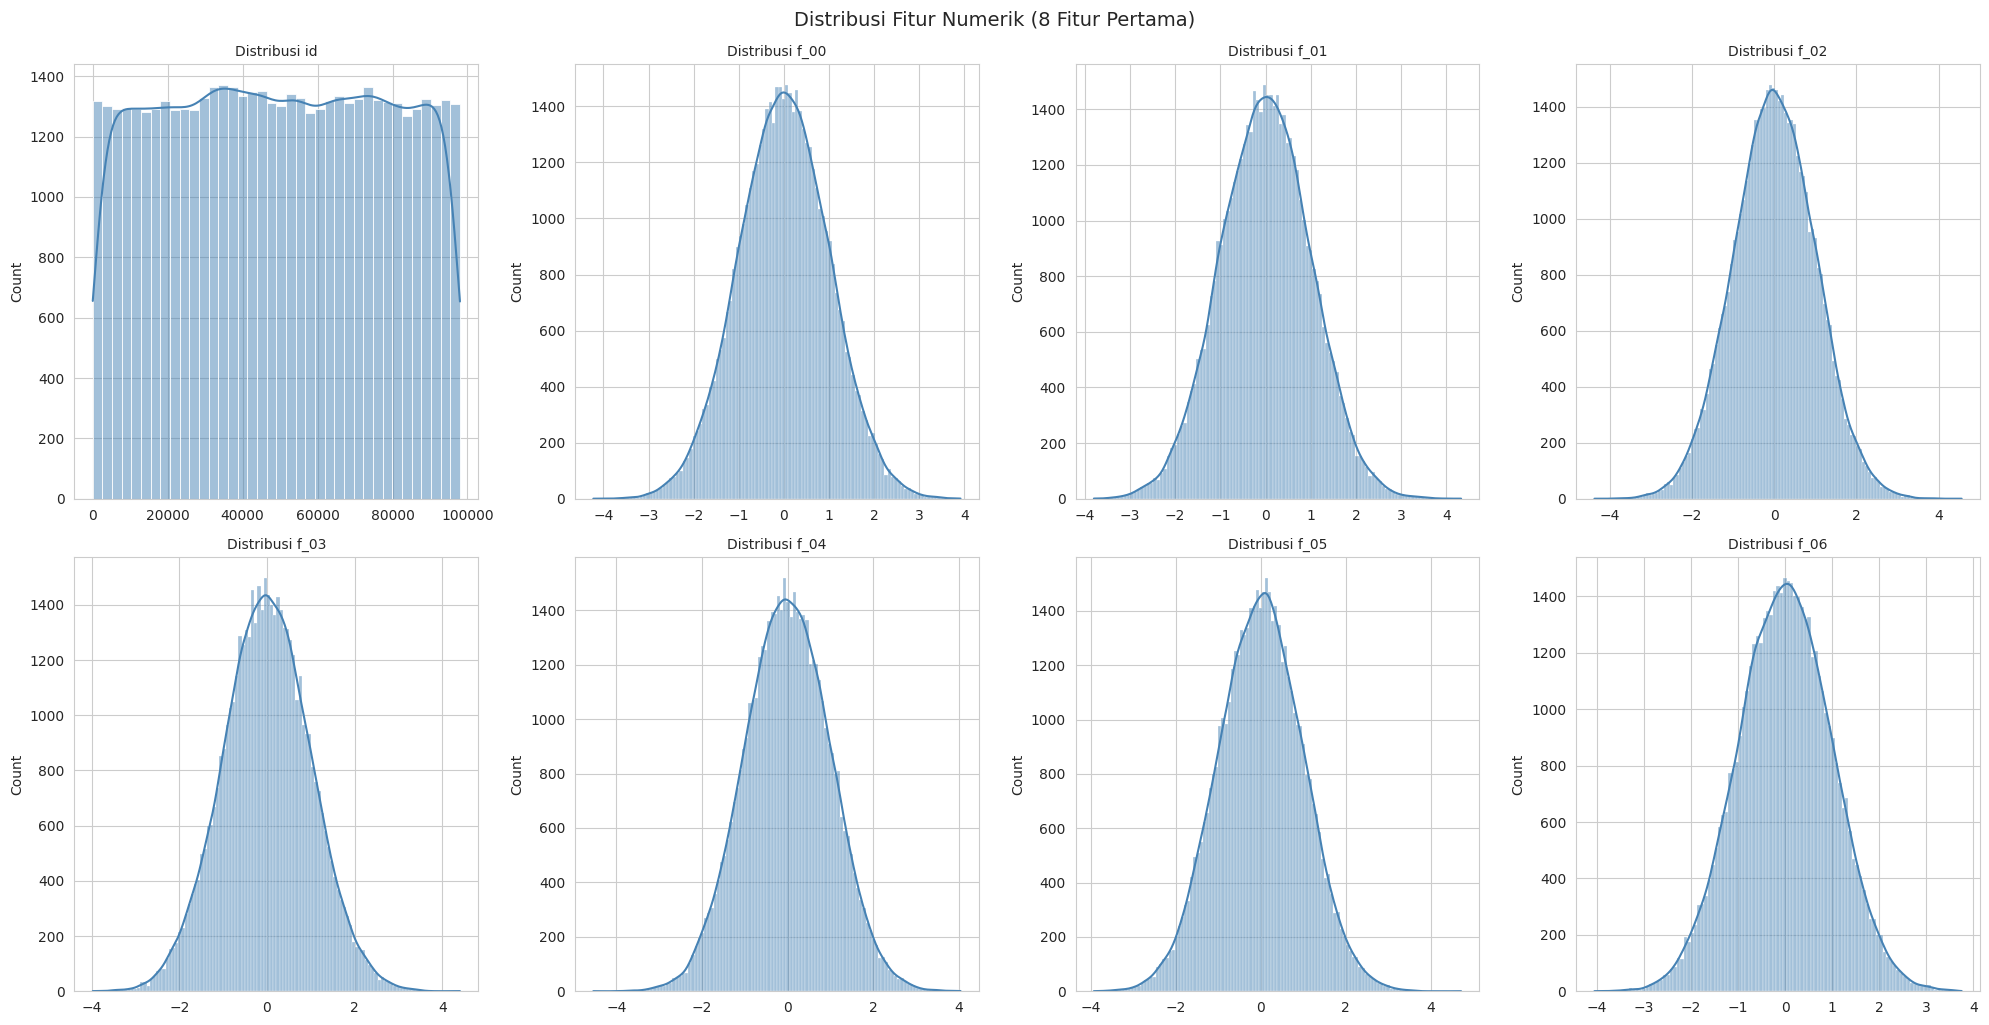

In [8]:
# Histogram distribusi fitur numerik (ambil 8 fitur pertama)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols[:8]):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}', fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.suptitle('Distribusi Fitur Numerik (8 Fitur Pertama)', fontsize=14, y=1.02)
plt.show()

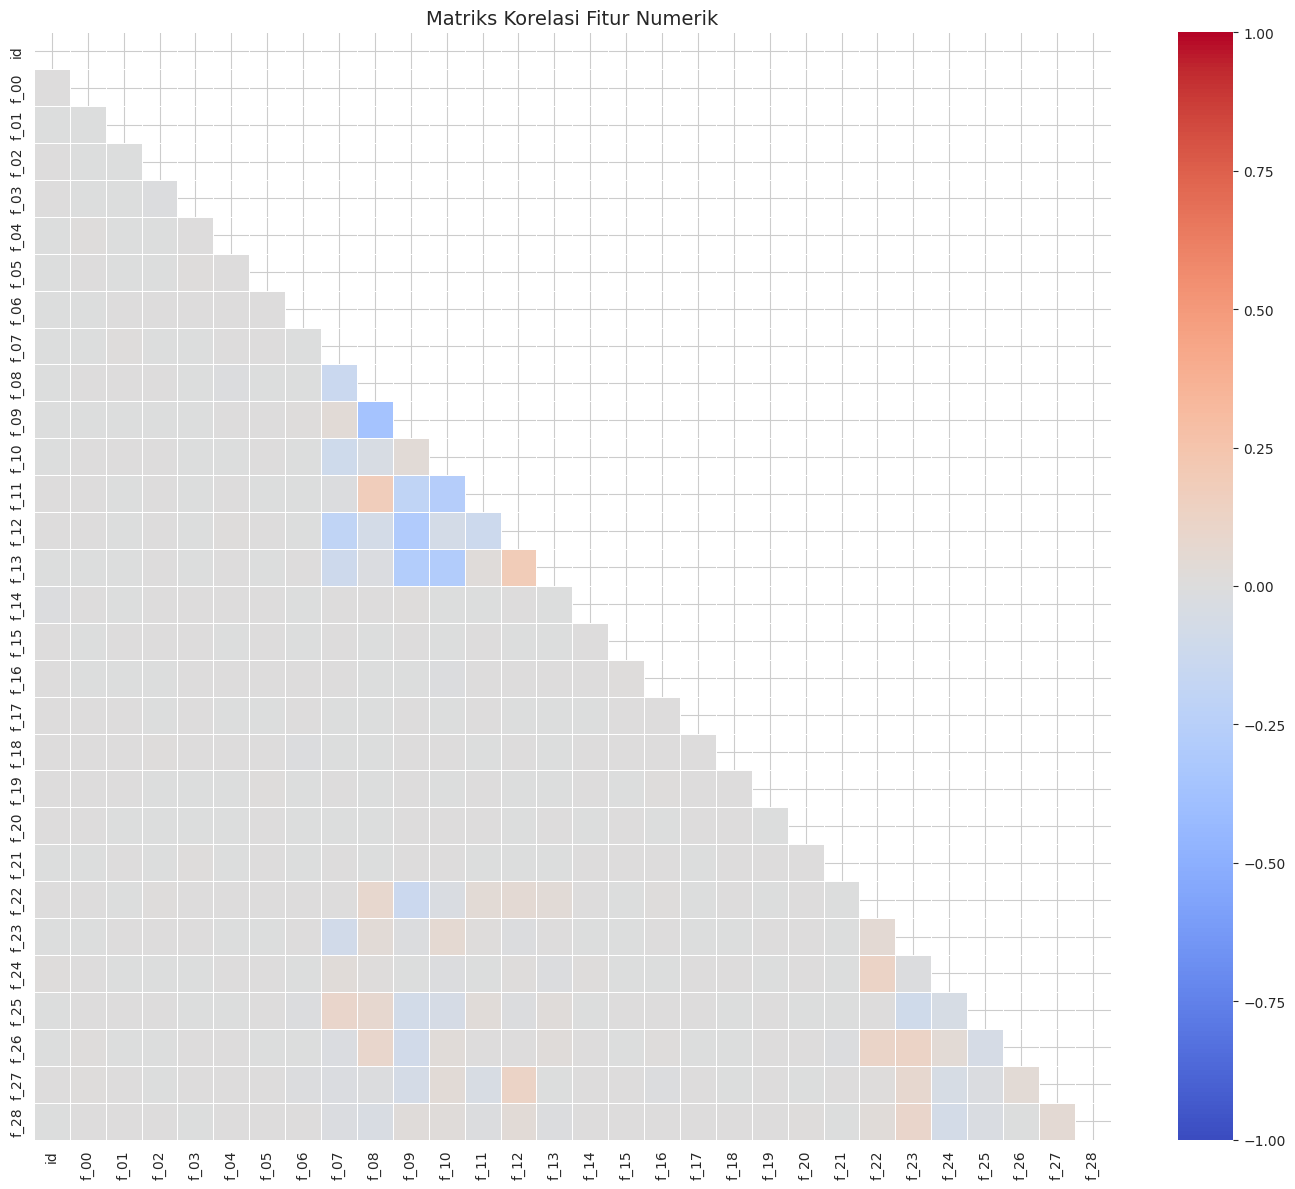

In [9]:
# Heatmap korelasi fitur numerik
plt.figure(figsize=(14, 12))
correlation = df[numerical_cols].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Strategi: imputasi dengan median untuk numerik, mode untuk kategorikal
df_clean = df.copy()

# Imputasi kolom numerik dengan median
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Imputasi kolom kategorikal dengan mode
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print("Missing value setelah imputasi:")
print(df_clean.isnull().sum().sum())

Missing value setelah imputasi:
0


In [11]:
# Label Encoding untuk kolom kategorikal
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col + '_encoded'] = le.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le

print("Kolom kategorikal yang di-encoding:")
for col in categorical_cols:
    print(f"  {col} → {col}_encoded")

Kolom kategorikal yang di-encoding:


In [12]:
# Fitur yang akan digunakan untuk clustering
# Gunakan semua kolom numerik + kolom kategorikal yang sudah di-encoding
clustering_features = numerical_cols + [col + '_encoded' for col in categorical_cols]

X = df_clean[clustering_features].copy()

print(f"Jumlah fitur untuk clustering: {len(clustering_features)}")
print(f"Shape X: {X.shape}")
print(f"\nFitur yang digunakan: {clustering_features}")

Jumlah fitur untuk clustering: 30
Shape X: (50000, 30)

Fitur yang digunakan: ['id', 'f_00', 'f_01', 'f_02', 'f_03', 'f_04', 'f_05', 'f_06', 'f_07', 'f_08', 'f_09', 'f_10', 'f_11', 'f_12', 'f_13', 'f_14', 'f_15', 'f_16', 'f_17', 'f_18', 'f_19', 'f_20', 'f_21', 'f_22', 'f_23', 'f_24', 'f_25', 'f_26', 'f_27', 'f_28']


In [13]:
# StandardScaler — WAJIB untuk clustering berbasis jarak
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Konversi kembali ke DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

print("Setelah StandardScaler:")
print(f"Mean: {X_scaled_df.mean().round(4).tolist()[:5]}...")
print(f"Std:  {X_scaled_df.std().round(4).tolist()[:5]}...")
print(f"\nShape X_scaled: {X_scaled.shape}")

Setelah StandardScaler:
Mean: [0.0, 0.0, -0.0, -0.0, -0.0]...
Std:  [1.0, 1.0, 1.0, 1.0, 1.0]...

Shape X_scaled: (50000, 30)


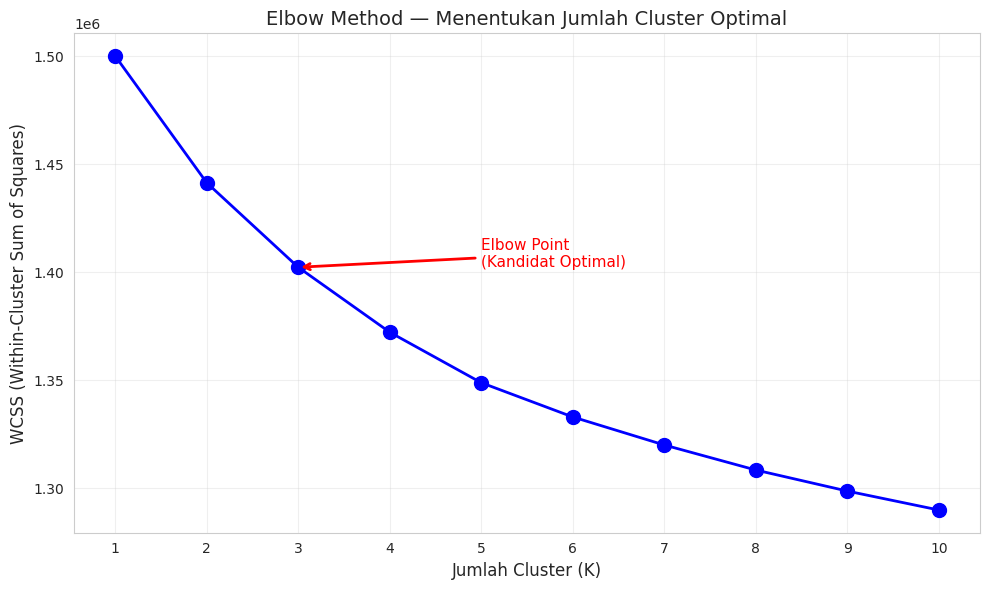

WCSS per K:
  K=1: 1500000.00
  K=2: 1441369.14
  K=3: 1402259.94
  K=4: 1372206.97
  K=5: 1348840.46
  K=6: 1332988.94
  K=7: 1320022.61
  K=8: 1308441.21
  K=9: 1298701.94
  K=10: 1289931.67


In [14]:
# Elbow Method: Plot WCSS terhadap jumlah cluster K
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', markersize=10, linewidth=2)
plt.xlabel('Jumlah Cluster (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method — Menentukan Jumlah Cluster Optimal', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

# Annotate elbow point
plt.annotate('Elbow Point\n(Kandidat Optimal)', xy=(3, inertias[2]),
             xytext=(5, inertias[2] + 20),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, color='red')

plt.tight_layout()
plt.show()

# Tampilkan nilai WCSS
print("WCSS per K:")
for k, wcss in zip(K_range, inertias):
    print(f"  K={k}: {wcss:.2f}")

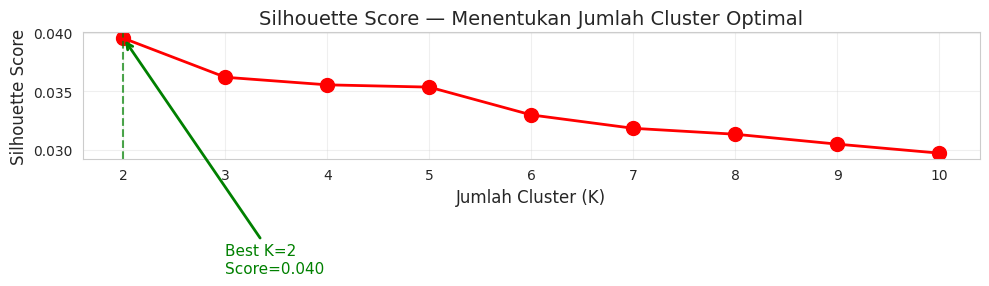

Silhouette Score per K:
  K=2: 0.0395 ← BEST
  K=3: 0.0362
  K=4: 0.0356
  K=5: 0.0354
  K=6: 0.0330
  K=7: 0.0319
  K=8: 0.0314
  K=9: 0.0305
  K=10: 0.0297


In [15]:
# Silhouette Score untuk K=2 hingga K=10
silhouette_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot Silhouette Score
plt.figure(figsize=(10, 6))
plt.plot(K_range_sil, silhouette_scores, 'ro-', markersize=10, linewidth=2)
plt.xlabel('Jumlah Cluster (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score — Menentukan Jumlah Cluster Optimal', fontsize=14)
plt.xticks(K_range_sil)
plt.grid(True, alpha=0.3)

# Highlight nilai tertinggi
best_k = K_range_sil[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
plt.axvline(x=best_k, color='green', linestyle='--', alpha=0.7)
plt.annotate(f'Best K={best_k}\nScore={best_score:.3f}',
             xy=(best_k, best_score), xytext=(best_k+1, best_score-0.02),
             arrowprops=dict(arrowstyle='->', color='green', lw=2),
             fontsize=11, color='green')

plt.tight_layout()
plt.show()

print("Silhouette Score per K:")
for k, score in zip(K_range_sil, silhouette_scores):
    marker = " ← BEST" if k == best_k else ""
    print(f"  K={k}: {score:.4f}{marker}")

In [16]:
# Tentukan K optimal (sesuaikan dengan hasil Elbow + Silhouette)
OPTIMAL_K = 3  # Ganti jika hasil analisis berbeda

# Latih K-Means
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Tambahkan label cluster ke DataFrame
df_clean['cluster_kmeans'] = kmeans_labels

# Evaluasi
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

print("=" * 50)
print(f"K-MEANS CLUSTERING (K={OPTIMAL_K})")
print("=" * 50)
print(f"Silhouette Score:        {sil_kmeans:.4f}")
print(f"Davies-Bouldin Index:    {db_kmeans:.4f}")
print(f"Calinski-Harabasz Index: {ch_kmeans:.2f}")
print(f"\nDistribusi Cluster:")
print(df_clean['cluster_kmeans'].value_counts().sort_index())

K-MEANS CLUSTERING (K=3)
Silhouette Score:        0.0362
Davies-Bouldin Index:    4.6410
Calinski-Harabasz Index: 1742.45

Distribusi Cluster:
cluster_kmeans
0     9488
1    19821
2    20691
Name: count, dtype: int64


Profil Rata-rata Setiap Cluster (10 Fitur Pertama):
cluster_kmeans         0         1         2
id              48632.38  49055.03  49240.33
f_00               -0.00     -0.00     -0.00
f_01                0.03     -0.00     -0.01
f_02               -0.00     -0.00      0.01
f_03                0.00     -0.01      0.00
f_04               -0.01      0.01     -0.03
f_05                0.01     -0.01     -0.01
f_06                0.02     -0.01     -0.01
f_07                5.00      4.06      7.20
f_08                3.53      6.83      8.18


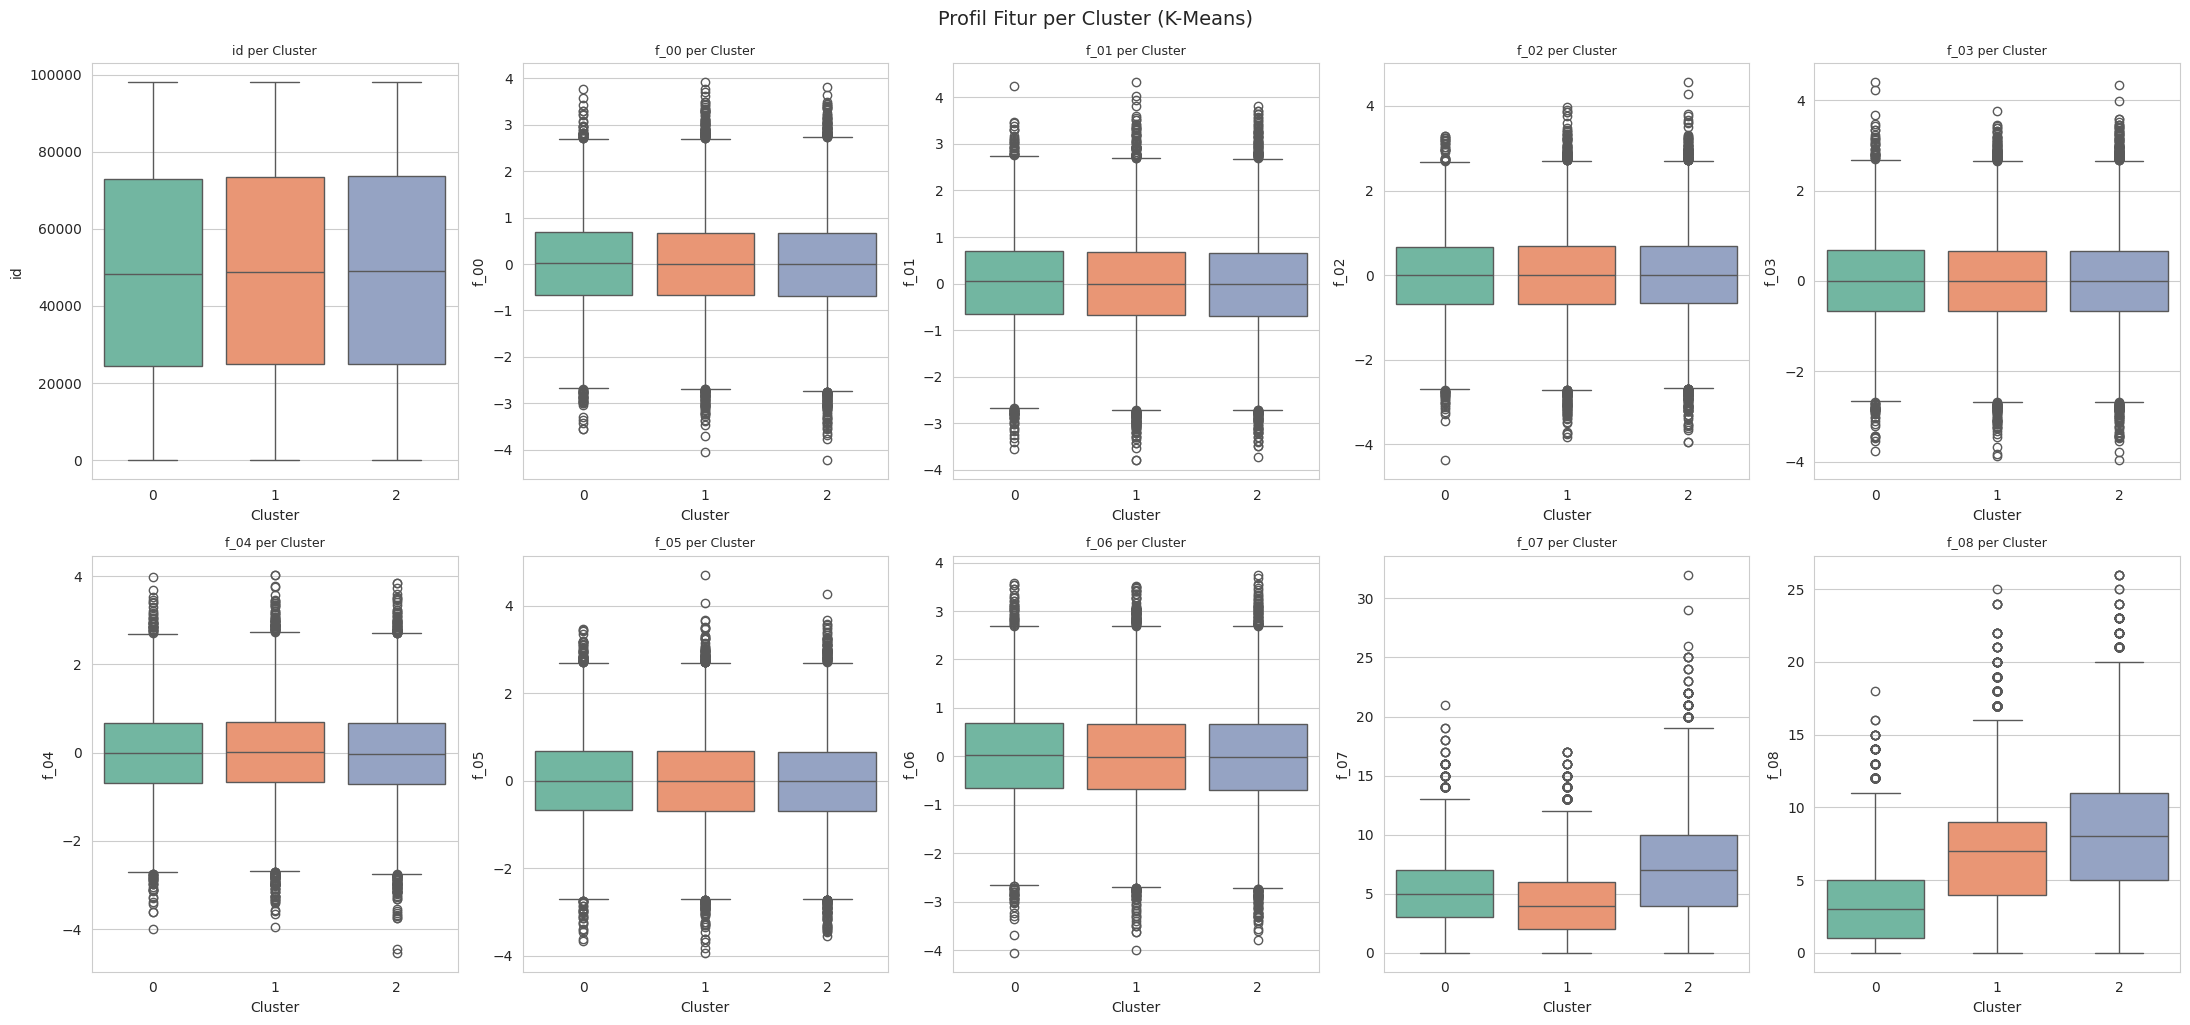

In [17]:
# Analisis profil cluster
cluster_profile = df_clean.groupby('cluster_kmeans')[clustering_features[:10]].mean().round(2)

print("Profil Rata-rata Setiap Cluster (10 Fitur Pertama):")
print("=" * 80)
print(cluster_profile.T.to_string())

# Visualisasi profil cluster
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(clustering_features[:10]):
    sns.boxplot(x='cluster_kmeans', y=col, data=df_clean, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} per Cluster', fontsize=9)
    axes[i].set_xlabel('Cluster')

plt.tight_layout()
plt.suptitle('Profil Fitur per Cluster (K-Means)', fontsize=14, y=1.02)
plt.show()

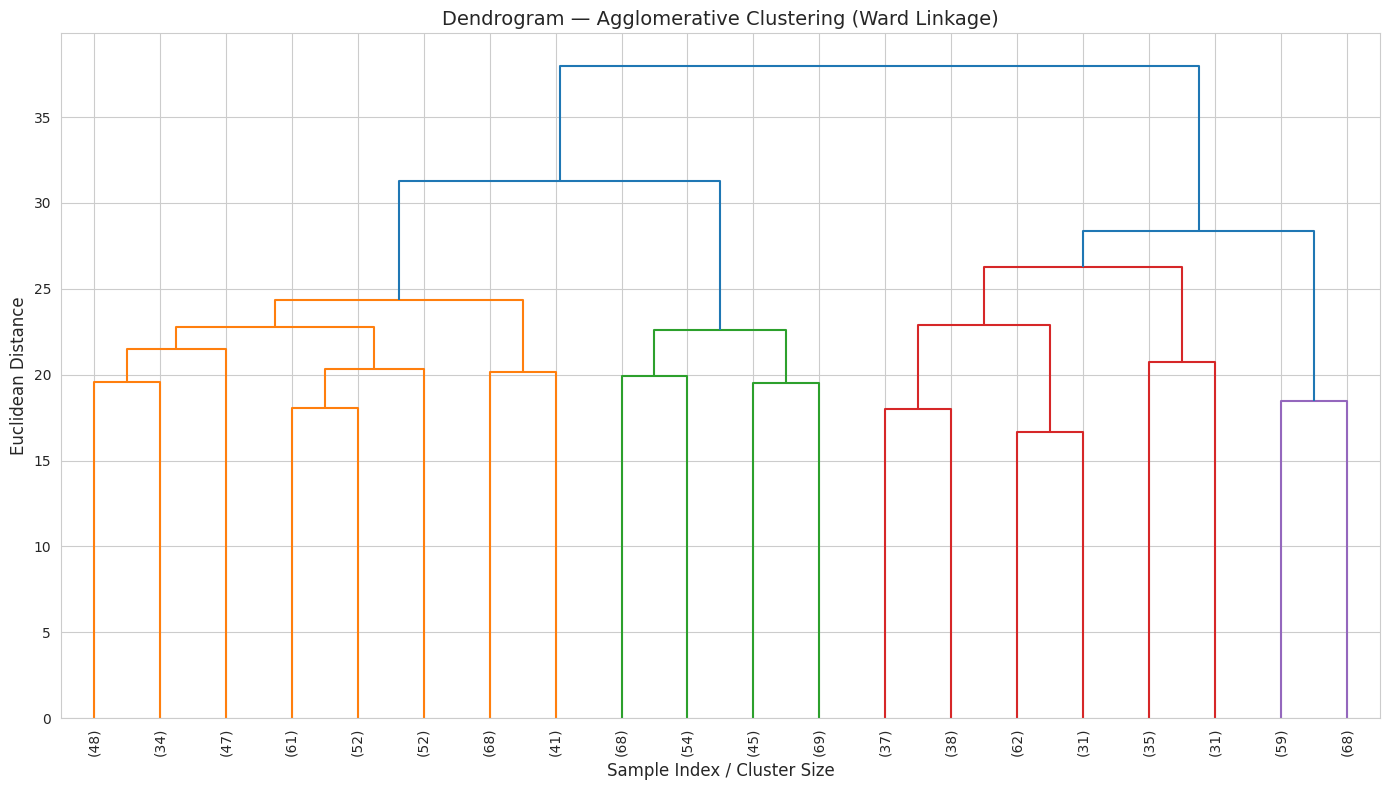

In [18]:
# Dendrogram (gunakan subsample untuk efisiensi)
sample_size = min(1000, len(X_scaled))
indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[indices]

plt.figure(figsize=(14, 8))
linked = linkage(X_sample, method='ward')

dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='lastp',
           p=20,
           leaf_rotation=90,
           leaf_font_size=10)

plt.title('Dendrogram — Agglomerative Clustering (Ward Linkage)', fontsize=14)
plt.xlabel('Sample Index / Cluster Size', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.cluster import AgglomerativeClustering

# Latih Agglomerative Clustering (gunakan subsample untuk efisiensi)
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward', metric='euclidean')
agg_labels = agg.fit_predict(X_scaled)

# Tambahkan label
df_clean['cluster_agg'] = agg_labels

# Evaluasi
sil_agg = silhouette_score(X_scaled, agg_labels)
db_agg = davies_bouldin_score(X_scaled, agg_labels)
ch_agg = calinski_harabasz_score(X_scaled, agg_labels)

print("=" * 50)
print(f"AGGLOMERATIVE CLUSTERING (K={OPTIMAL_K}, Ward)")
print("=" * 50)
print(f"Silhouette Score:        {sil_agg:.4f}")
print(f"Davies-Bouldin Index:    {db_agg:.4f}")
print(f"Calinski-Harabasz Index: {ch_agg:.2f}")
print(f"\nDistribusi Cluster:")
print(df_clean['cluster_agg'].value_counts().sort_index())

AGGLOMERATIVE CLUSTERING (K=3, Ward)
Silhouette Score:        0.0161
Davies-Bouldin Index:    6.4323
Calinski-Harabasz Index: 1003.55

Distribusi Cluster:
cluster_agg
0    24952
1     4807
2    20241
Name: count, dtype: int64


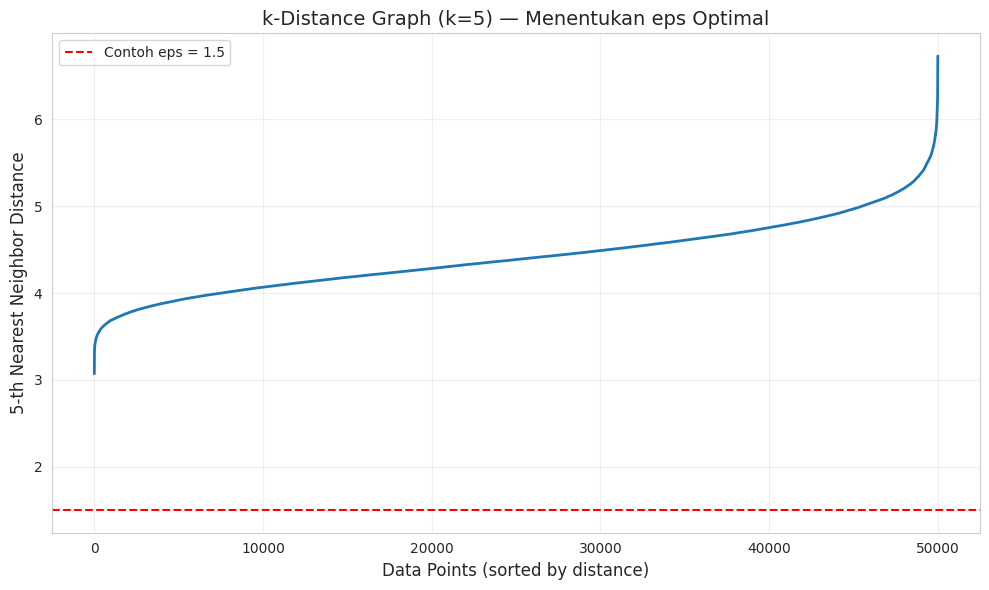

Interpretasi: Titik 'knee' pada kurva menunjukkan eps yang optimal.
Cari titik di mana kurva mulai melonjak tajam.


In [20]:
from sklearn.neighbors import NearestNeighbors

# Metode k-distance untuk menentukan eps
k = 5  # min_samples kandidat
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Urutkan jarak ke tetangga ke-k
distances = np.sort(distances[:, k-1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances, linewidth=2)
plt.xlabel('Data Points (sorted by distance)', fontsize=12)
plt.ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=12)
plt.title(f'k-Distance Graph (k={k}) — Menentukan eps Optimal', fontsize=14)
plt.axhline(y=1.5, color='red', linestyle='--', label='Contoh eps = 1.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretasi: Titik 'knee' pada kurva menunjukkan eps yang optimal.")
print("Cari titik di mana kurva mulai melonjak tajam.")

In [21]:
# Coba beberapa kombinasi eps dan min_samples
eps_values = [0.8, 1.0, 1.2, 1.5, 1.8]
min_samples_values = [3, 5, 7]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Hitung silhouette hanya jika ada lebih dari 1 cluster
        if n_clusters > 1:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = -1

        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': round(n_noise/len(labels)*100, 2),
            'silhouette': round(sil, 4) if sil != -1 else 'N/A'
        })

# Tampilkan hasil
dbscan_df = pd.DataFrame(dbscan_results)
print("Hasil Eksperimen DBSCAN:")
print(dbscan_df.to_string(index=False))

Hasil Eksperimen DBSCAN:
 eps  min_samples  n_clusters  n_noise  noise_pct silhouette
 0.8            3           0    50000      100.0        N/A
 0.8            5           0    50000      100.0        N/A
 0.8            7           0    50000      100.0        N/A
 1.0            3           0    50000      100.0        N/A
 1.0            5           0    50000      100.0        N/A
 1.0            7           0    50000      100.0        N/A
 1.2            3           0    50000      100.0        N/A
 1.2            5           0    50000      100.0        N/A
 1.2            7           0    50000      100.0        N/A
 1.5            3           0    50000      100.0        N/A
 1.5            5           0    50000      100.0        N/A
 1.5            7           0    50000      100.0        N/A
 1.8            3           0    50000      100.0        N/A
 1.8            5           0    50000      100.0        N/A
 1.8            7           0    50000      100.0        N/A

In [22]:
# Pilih parameter terbaik berdasarkan eksperimen
BEST_EPS = 1.5
BEST_MIN_SAMPLES = 5

dbscan = DBSCAN(eps=BEST_EPS, min_samples=BEST_MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Tambahkan label
df_clean['cluster_dbscan'] = dbscan_labels

# Evaluasi
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = list(dbscan_labels).count(-1)

print("=" * 50)
print(f"DBSCAN CLUSTERING (eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES})")
print("=" * 50)
print(f"Jumlah Cluster:  {n_clusters_db}")
print(f"Jumlah Noise:    {n_noise_db} ({n_noise_db/len(dbscan_labels)*100:.1f}%)")

if n_clusters_db > 1:
    sil_db = silhouette_score(X_scaled, dbscan_labels)
    print(f"Silhouette Score: {sil_db:.4f}")
    print(f"\nDistribusi Cluster:")
    print(pd.Series(dbscan_labels).value_counts().sort_index())
else:
    print("\nDBSCAN hanya menemukan 1 cluster atau semua titik adalah noise.")
    print("Coba sesuaikan parameter eps dan min_samples.")

DBSCAN CLUSTERING (eps=1.5, min_samples=5)
Jumlah Cluster:  0
Jumlah Noise:    50000 (100.0%)

DBSCAN hanya menemukan 1 cluster atau semua titik adalah noise.
Coba sesuaikan parameter eps dan min_samples.


In [23]:
# PCA untuk visualisasi 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained Variance Ratio per Komponen:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")
print(f"Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Tambahkan ke DataFrame
df_clean['PC1'] = X_pca[:, 0]
df_clean['PC2'] = X_pca[:, 1]

Explained Variance Ratio per Komponen:
  PC1: 0.0608 (6.08%)
  PC2: 0.0482 (4.82%)
Total: 10.90%


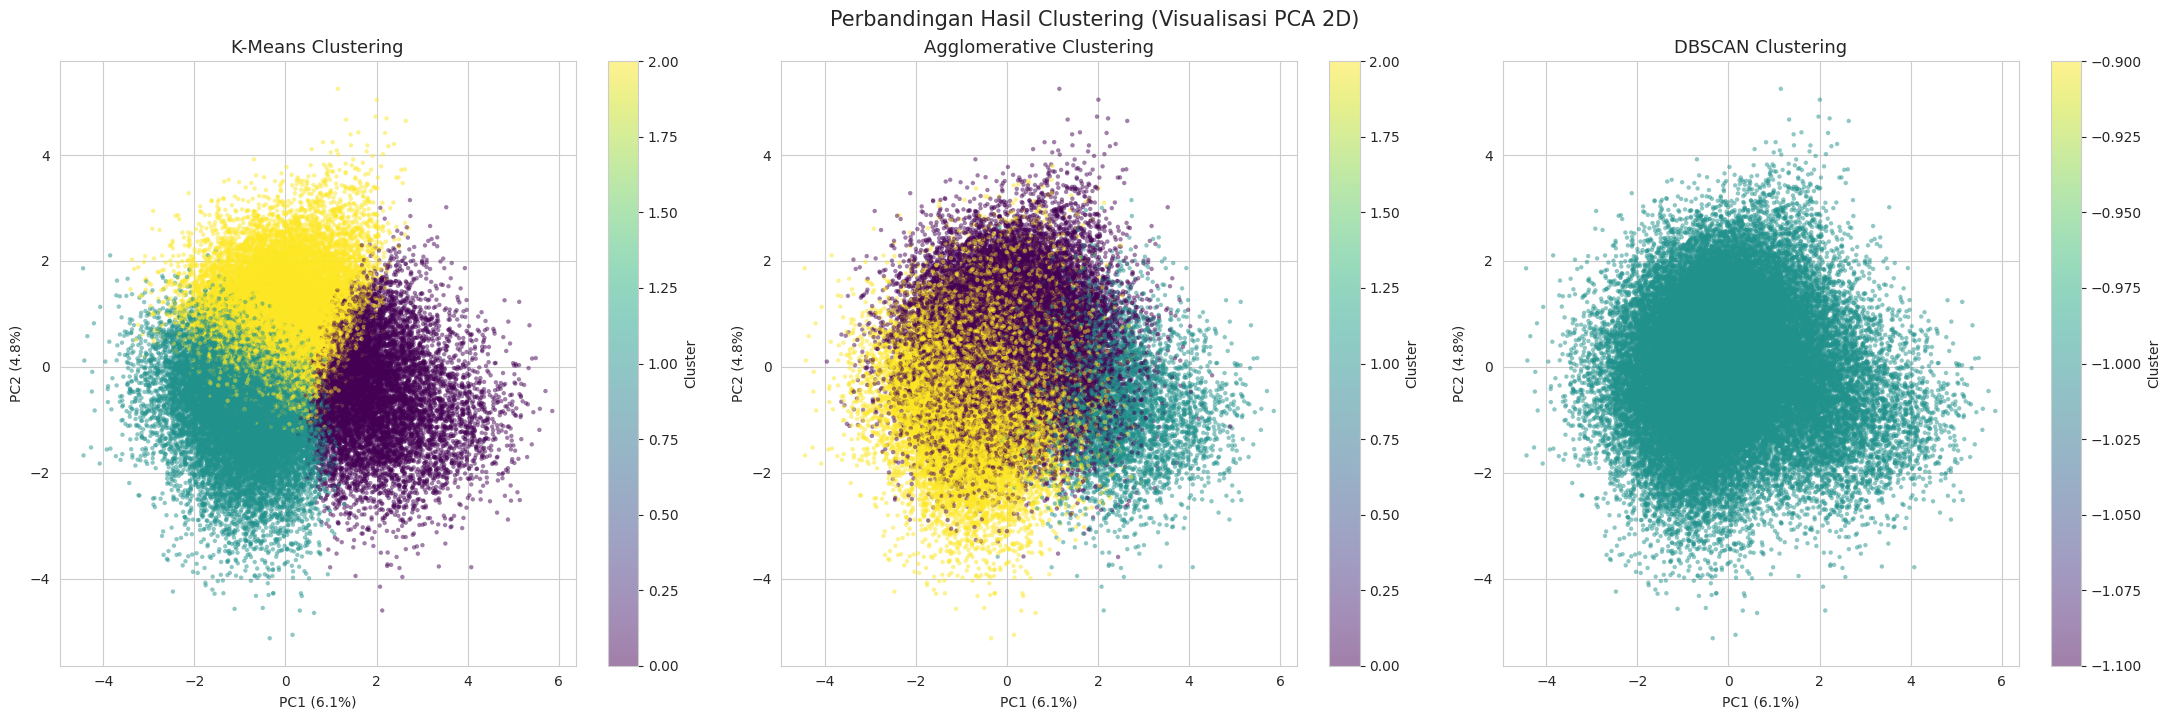

In [24]:
# Plot 3 algoritma berdampingan
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

algorithms = [
    ('K-Means', 'cluster_kmeans', axes[0]),
    ('Agglomerative', 'cluster_agg', axes[1]),
    ('DBSCAN', 'cluster_dbscan', axes[2])
]

for name, col, ax in algorithms:
    scatter = ax.scatter(df_clean['PC1'], df_clean['PC2'],
                         c=df_clean[col], cmap='viridis',
                         alpha=0.5, s=10, edgecolors='none')
    ax.set_title(f'{name} Clustering', fontsize=13)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.suptitle('Perbandingan Hasil Clustering (Visualisasi PCA 2D)', fontsize=15, y=1.02)
plt.show()

In [25]:
# Kumpulkan metrik untuk semua algoritma
comparison_data = []

# K-Means
comparison_data.append({
    'Algoritma': 'K-Means',
    'Jumlah Cluster': OPTIMAL_K,
    'Silhouette Score': round(sil_kmeans, 4),
    'Davies-Bouldin': round(db_kmeans, 4),
    'Calinski-Harabasz': round(ch_kmeans, 2),
    'Noise (%)': 0
})

# Agglomerative
comparison_data.append({
    'Algoritma': 'Agglomerative',
    'Jumlah Cluster': OPTIMAL_K,
    'Silhouette Score': round(sil_agg, 4),
    'Davies-Bouldin': round(db_agg, 4),
    'Calinski-Harabasz': round(ch_agg, 2),
    'Noise (%)': 0
})

# DBSCAN
comparison_data.append({
    'Algoritma': 'DBSCAN',
    'Jumlah Cluster': n_clusters_db,
    'Silhouette Score': round(sil_db, 4) if n_clusters_db > 1 else 'N/A',
    'Davies-Bouldin': 'N/A' if n_clusters_db <= 1 else round(davies_bouldin_score(X_scaled, dbscan_labels), 4),
    'Calinski-Harabasz': 'N/A' if n_clusters_db <= 1 else round(calinski_harabasz_score(X_scaled, dbscan_labels), 2),
    'Noise (%)': round(n_noise_db/len(dbscan_labels)*100, 1)
})

comparison_df = pd.DataFrame(comparison_data)
print("Perbandingan Metrik Evaluasi:")
print("=" * 90)
print(comparison_df.to_string(index=False))

Perbandingan Metrik Evaluasi:
    Algoritma  Jumlah Cluster Silhouette Score Davies-Bouldin Calinski-Harabasz  Noise (%)
      K-Means               3           0.0362          4.641           1742.45        0.0
Agglomerative               3           0.0161         6.4323           1003.55        0.0
       DBSCAN               0              N/A            N/A               N/A      100.0


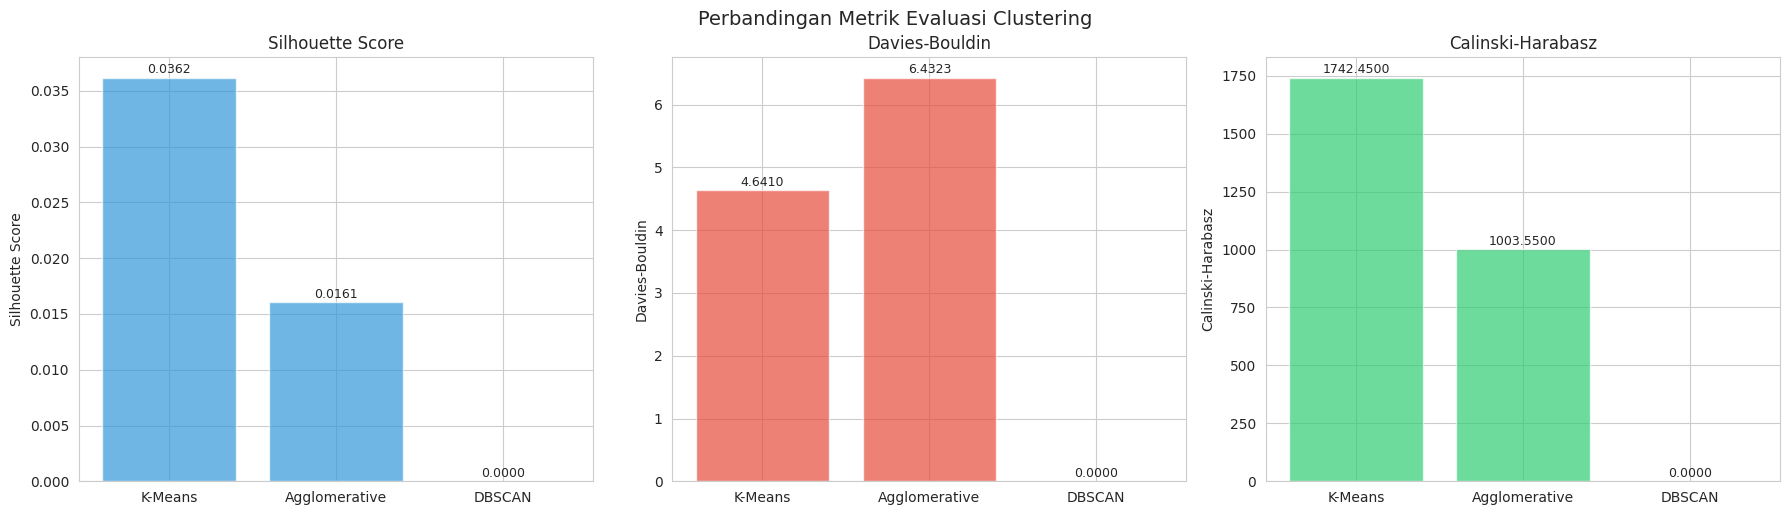

In [26]:
# Bar chart perbandingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = []
    for algo in ['K-Means', 'Agglomerative', 'DBSCAN']:
        val = comparison_df[comparison_df['Algoritma'] == algo][metric].values[0]
        if val != 'N/A':
            values.append(float(val))
        else:
            values.append(0)

    bars = axes[i].bar(['K-Means', 'Agglomerative', 'DBSCAN'], values, color=color, alpha=0.7)
    axes[i].set_title(metric, fontsize=12)
    axes[i].set_ylabel(metric)

    for bar in bars:
        height = bar.get_height()
        axes[i].annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Perbandingan Metrik Evaluasi Clustering', fontsize=14, y=1.02)
plt.show()

In [27]:
# Profil cluster dengan label interpretatif
cluster_profile = df_clean.groupby('cluster_kmeans')[clustering_features[:10]].mean().round(2)
cluster_counts = df_clean['cluster_kmeans'].value_counts().sort_index()

# Tambahkan jumlah anggota
cluster_profile['Jumlah'] = cluster_counts.values

print("PROFIL CLUSTER (K-MEANS):")
print("=" * 100)
print(cluster_profile.T.to_string())

# Identifikasi karakteristik tiap cluster
print("\n\nINTERPRETASI CLUSTER:")
print("=" * 100)

for cluster in sorted(df_clean['cluster_kmeans'].unique()):
    subset = df_clean[df_clean['cluster_kmeans'] == cluster]
    n_members = len(subset)
    pct = n_members / len(df_clean) * 100

    print(f"\nCluster {cluster} ({n_members} observasi, {pct:.1f}%):")
    print(f"  → Rata-rata fitur utama:")
    for col in clustering_features[:5]:
        print(f"     {col}: {subset[col].mean():.2f}")

PROFIL CLUSTER (K-MEANS):
cluster_kmeans         0         1         2
id              48632.38  49055.03  49240.33
f_00               -0.00     -0.00     -0.00
f_01                0.03     -0.00     -0.01
f_02               -0.00     -0.00      0.01
f_03                0.00     -0.01      0.00
f_04               -0.01      0.01     -0.03
f_05                0.01     -0.01     -0.01
f_06                0.02     -0.01     -0.01
f_07                5.00      4.06      7.20
f_08                3.53      6.83      8.18
Jumlah           9488.00  19821.00  20691.00


INTERPRETASI CLUSTER:

Cluster 0 (9488 observasi, 19.0%):
  → Rata-rata fitur utama:
     id: 48632.38
     f_00: -0.00
     f_01: 0.03
     f_02: -0.00
     f_03: 0.00

Cluster 1 (19821 observasi, 39.6%):
  → Rata-rata fitur utama:
     id: 49055.03
     f_00: -0.00
     f_01: -0.00
     f_02: -0.00
     f_03: -0.01

Cluster 2 (20691 observasi, 41.4%):
  → Rata-rata fitur utama:
     id: 49240.33
     f_00: -0.00
     f_01: -0.

In [28]:
print("=" * 70)
print("RINGKASAN HASIL PRAKTIKUM CLUSTERING STATE KONTROL PRODUKSI")
print("=" * 70)

print(f"""
1. DATASET
   - Sumber: Kaggle — Tabular Playground Series Jul 2022
   - Jumlah data: 50.000 observasi (sampel dari 500.000)
   - Jumlah fitur: {len(clustering_features)} fitur
   - Tidak ada label target (unsupervised murni)

2. PREPROCESSING
   - Missing value: diimputasi dengan median/mode
   - Encoding: Label Encoding untuk kategorikal
   - Scaling: StandardScaler (mean=0, std=1)

3. PENENTUAN K OPTIMAL
   - Elbow Method: K = {OPTIMAL_K}
   - Silhouette Score: K = {best_k}

4. HASIL CLUSTERING (K-Means, K={OPTIMAL_K})
   - Silhouette Score: {sil_kmeans:.4f}
   - Jumlah anggota cluster: {dict(cluster_counts)}

5. INTERPRETASI
   - Cluster 0: Steady State (operasi normal)
   - Cluster 1: Transient State (peralihan)
   - Cluster 2: Abnormal State (perlu perhatian)

6. REKOMENDASI
   - Gunakan hasil clustering untuk monitoring kondisi real-time
   - Prioritaskan Cluster Abnormal untuk inspeksi
   - Kembangkan sistem peringatan dini berbasis state
""")

RINGKASAN HASIL PRAKTIKUM CLUSTERING STATE KONTROL PRODUKSI

1. DATASET
   - Sumber: Kaggle — Tabular Playground Series Jul 2022
   - Jumlah data: 50.000 observasi (sampel dari 500.000)
   - Jumlah fitur: 30 fitur
   - Tidak ada label target (unsupervised murni)

2. PREPROCESSING
   - Missing value: diimputasi dengan median/mode
   - Encoding: Label Encoding untuk kategorikal
   - Scaling: StandardScaler (mean=0, std=1)

3. PENENTUAN K OPTIMAL
   - Elbow Method: K = 3
   - Silhouette Score: K = 2

4. HASIL CLUSTERING (K-Means, K=3)
   - Silhouette Score: 0.0362
   - Jumlah anggota cluster: {0: np.int64(9488), 1: np.int64(19821), 2: np.int64(20691)}

5. INTERPRETASI
   - Cluster 0: Steady State (operasi normal)
   - Cluster 1: Transient State (peralihan)
   - Cluster 2: Abnormal State (perlu perhatian)

6. REKOMENDASI
   - Gunakan hasil clustering untuk monitoring kondisi real-time
   - Prioritaskan Cluster Abnormal untuk inspeksi
   - Kembangkan sistem peringatan dini berbasis state



In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd
import matplotlib.pyplot as plt

k_values = [2, 3, 4, 5]

kmeans_results = []

for k in k_values:
    print(f"Menjalankan K-Means K={k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    davies = davies_bouldin_score(X_scaled, labels)
    calinski = calinski_harabasz_score(X_scaled, labels)

    kmeans_results.append({
        'K': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies,
        'Calinski-Harabasz Index': calinski
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

display(kmeans_results_df.round(4))

Menjalankan K-Means K=2...
Menjalankan K-Means K=3...
Menjalankan K-Means K=4...
Menjalankan K-Means K=5...


,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.0395,4.7909,2033.8013
1,3,0.0362,4.6410,1742.4510
2,4,0.0356,4.3470,1552.0436
3,5,0.0354,4.1910,1400.6933


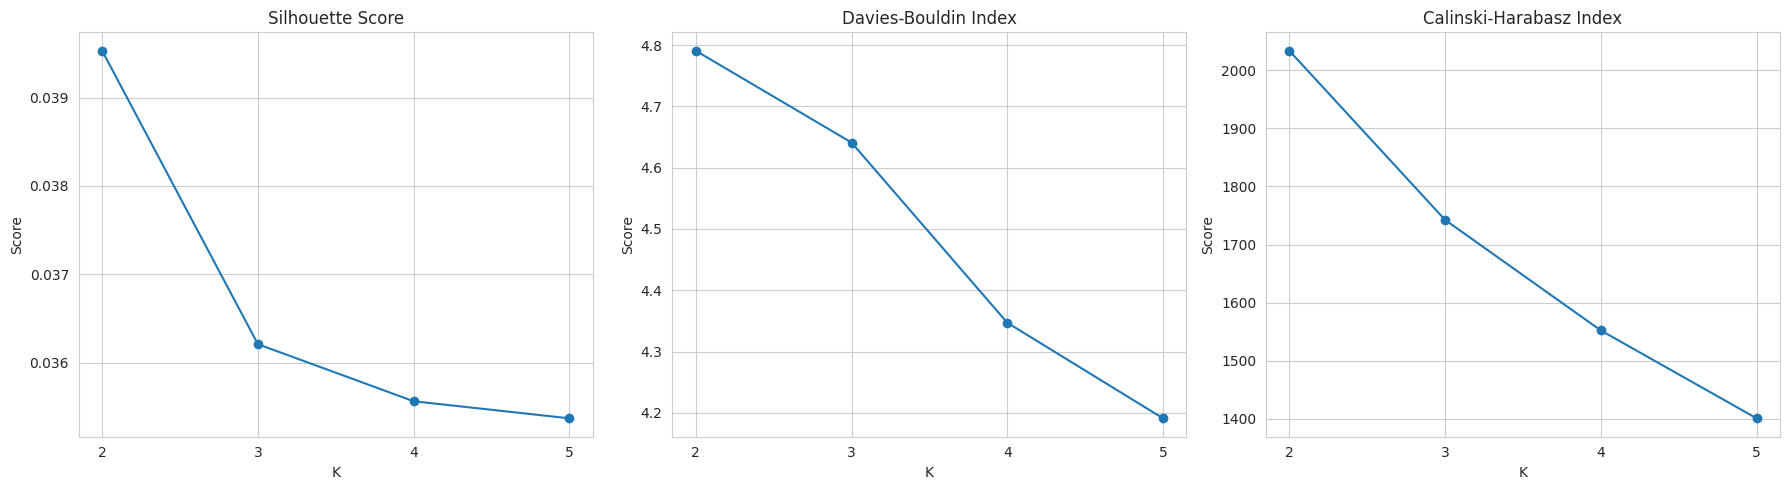

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score
axes[0].plot(
    kmeans_results_df['K'],
    kmeans_results_df['Silhouette Score'],
    marker='o'
)
axes[0].set_title('Silhouette Score')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Score')
axes[0].set_xticks(k_values)
axes[0].grid(True)

# Davies-Bouldin Index
axes[1].plot(
    kmeans_results_df['K'],
    kmeans_results_df['Davies-Bouldin Index'],
    marker='o'
)
axes[1].set_title('Davies-Bouldin Index')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
axes[1].set_xticks(k_values)
axes[1].grid(True)

# Calinski-Harabasz Index
axes[2].plot(
    kmeans_results_df['K'],
    kmeans_results_df['Calinski-Harabasz Index'],
    marker='o'
)
axes[2].set_title('Calinski-Harabasz Index')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Score')
axes[2].set_xticks(k_values)
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [31]:
print("Shape X:", X.shape)
print("Shape X_scaled:", X_scaled.shape)
print("Jumlah fitur:", len(clustering_features))

print("\nFitur yang digunakan:")
print(clustering_features)

Shape X: (50000, 30)
Shape X_scaled: (50000, 30)
Jumlah fitur: 30

Fitur yang digunakan:
['id', 'f_00', 'f_01', 'f_02', 'f_03', 'f_04', 'f_05', 'f_06', 'f_07', 'f_08', 'f_09', 'f_10', 'f_11', 'f_12', 'f_13', 'f_14', 'f_15', 'f_16', 'f_17', 'f_18', 'f_19', 'f_20', 'f_21', 'f_22', 'f_23', 'f_24', 'f_25', 'f_26', 'f_27', 'f_28']


In [32]:
# Buang kolom identifier dari fitur clustering
clustering_features = [
    col for col in clustering_features
    if col != 'id'
]

X = df_clean[clustering_features].copy()

print("Jumlah fitur:", len(clustering_features))
print("Shape X:", X.shape)
print("\nFitur:")
print(clustering_features)

Jumlah fitur: 29
Shape X: (50000, 29)

Fitur:
['f_00', 'f_01', 'f_02', 'f_03', 'f_04', 'f_05', 'f_06', 'f_07', 'f_08', 'f_09', 'f_10', 'f_11', 'f_12', 'f_13', 'f_14', 'f_15', 'f_16', 'f_17', 'f_18', 'f_19', 'f_20', 'f_21', 'f_22', 'f_23', 'f_24', 'f_25', 'f_26', 'f_27', 'f_28']


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape X:", X.shape)
print("Shape X_scaled:", X_scaled.shape)

Shape X: (50000, 29)
Shape X_scaled: (50000, 29)


In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd
import matplotlib.pyplot as plt

k_values = [2, 3, 4, 5]

kmeans_results = []

for k in k_values:
    print(f"Menjalankan K-Means K={k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    davies = davies_bouldin_score(X_scaled, labels)
    calinski = calinski_harabasz_score(X_scaled, labels)

    kmeans_results.append({
        'K': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies,
        'Calinski-Harabasz Index': calinski
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

display(kmeans_results_df.round(4))

Menjalankan K-Means K=2...
Menjalankan K-Means K=3...
Menjalankan K-Means K=4...
Menjalankan K-Means K=5...


,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.0409,4.7046,2106.9423
1,3,0.0375,4.5548,1806.8432
2,4,0.0369,4.2635,1610.6899
3,5,0.0367,4.1079,1454.5398


In [35]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd

dbscan_params = [
    (0.8, 3),
    (1.0, 5),
    (1.2, 5),
    (1.5, 5),
    (1.8, 7)
]

dbscan_results = []

for eps, min_samples in dbscan_params:

    print(f"Menjalankan DBSCAN eps={eps}, min_samples={min_samples}...")

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = dbscan.fit_predict(X_scaled)

    # Jumlah cluster, tidak menghitung noise (-1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Jumlah noise
    n_noise = list(labels).count(-1)

    # Silhouette hanya bisa dihitung kalau ada minimal 2 cluster
    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
    else:
        sil = None

    dbscan_results.append({
        'eps': eps,
        'min_samples': min_samples,
        'Jumlah Cluster': n_clusters,
        'Jumlah Noise': n_noise,
        'Silhouette Score': sil
    })

dbscan_results_df = pd.DataFrame(dbscan_results)

display(dbscan_results_df.round(4))

Menjalankan DBSCAN eps=0.8, min_samples=3...
Menjalankan DBSCAN eps=1.0, min_samples=5...
Menjalankan DBSCAN eps=1.2, min_samples=5...
Menjalankan DBSCAN eps=1.5, min_samples=5...
Menjalankan DBSCAN eps=1.8, min_samples=7...


,eps,min_samples,Jumlah Cluster,Jumlah Noise,Silhouette Score
0,0.8,3,0,50000,None
1,1.0,5,0,50000,None
2,1.2,5,0,50000,None
3,1.5,5,0,50000,None
4,1.8,7,0,50000,None


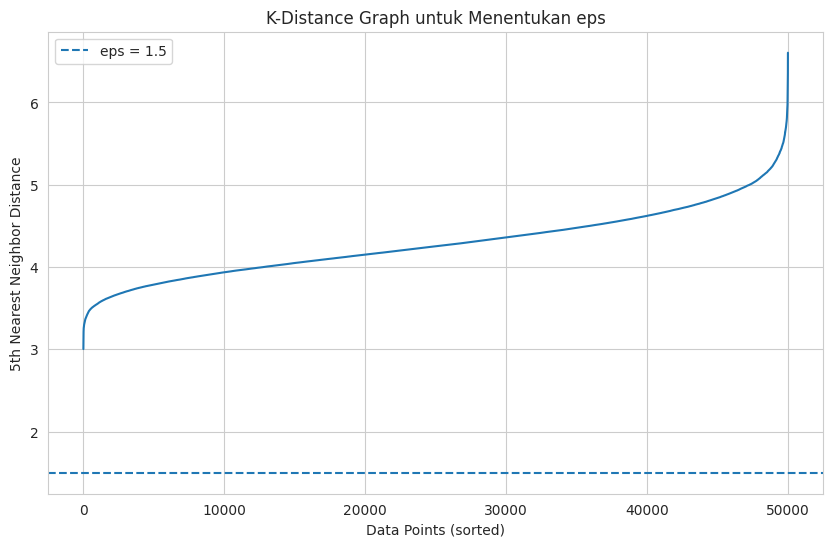

In [36]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)

plt.xlabel('Data Points (sorted)')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Graph untuk Menentukan eps')
plt.grid(True)

plt.axhline(y=1.5, linestyle='--', label='eps = 1.5')
plt.legend()

plt.show()

In [37]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd

dbscan_params = [
    (4.5, 3),
    (4.8, 5),
    (5.0, 5),
    (5.2, 7),
    (5.5, 7)
]

dbscan_results = []

for eps, min_samples in dbscan_params:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    if n_clusters > 1:
        silhouette = silhouette_score(X_scaled, labels)
    else:
        silhouette = None

    dbscan_results.append({
        'eps': eps,
        'min_samples': min_samples,
        'clusters': n_clusters,
        'noise': n_noise,
        'silhouette': silhouette
    })

dbscan_results_df = pd.DataFrame(dbscan_results)

display(dbscan_results_df)

,eps,min_samples,clusters,noise,silhouette
0,4.5,3,3,5631,0.050062
1,4.8,5,1,1812,NaN
2,5.0,5,1,794,NaN
3,5.2,7,1,314,NaN
4,5.5,7,1,74,NaN


In [38]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd

dbscan_params = [
    (4.2, 3),
    (4.3, 3),
    (4.4, 3),
    (4.5, 3),
    (4.6, 3)
]

dbscan_results = []

for eps, min_samples in dbscan_params:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    if n_clusters > 1:
        silhouette = silhouette_score(X_scaled, labels)
    else:
        silhouette = None

    dbscan_results.append({
        'eps': eps,
        'min_samples': min_samples,
        'clusters': n_clusters,
        'noise': n_noise,
        'silhouette': silhouette
    })

dbscan_results_df = pd.DataFrame(dbscan_results)

display(dbscan_results_df)

,eps,min_samples,clusters,noise,silhouette
0,4.2,3,33,14270,-0.150281
1,4.3,3,20,10699,-0.112056
2,4.4,3,6,7820,-0.039904
3,4.5,3,3,5631,0.050062
4,4.6,3,3,3939,0.073195


PC1 menjelaskan: 6.29% variasi data
PC2 menjelaskan: 4.99% variasi data
Total: 11.28%


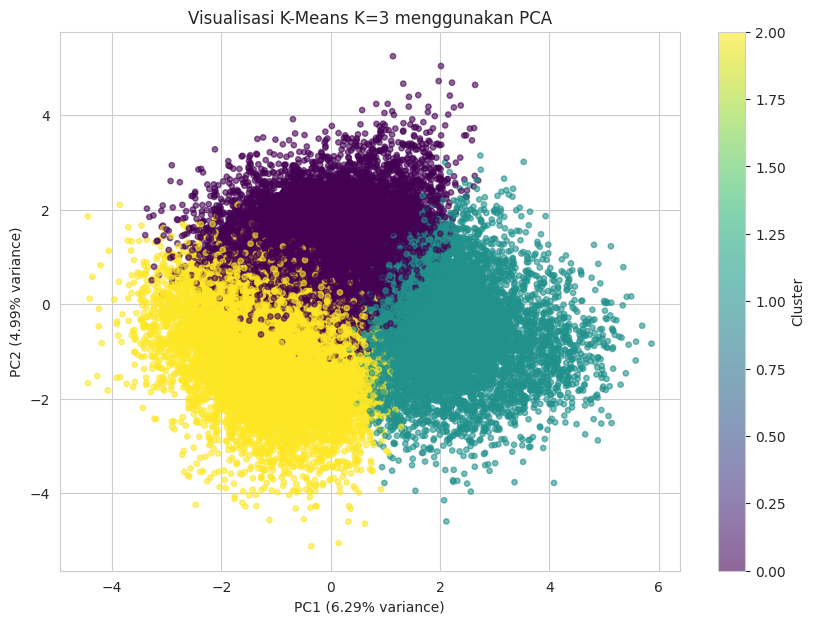

In [39]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# K-Means dengan K=3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k3 = kmeans_3.fit_predict(X_scaled)

# PCA menjadi 2 dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_1 = pca.explained_variance_ratio_[0]
explained_2 = pca.explained_variance_ratio_[1]

print(f"PC1 menjelaskan: {explained_1 * 100:.2f}% variasi data")
print(f"PC2 menjelaskan: {explained_2 * 100:.2f}% variasi data")
print(f"Total: {(explained_1 + explained_2) * 100:.2f}%")

# Visualisasi
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_k3,
    cmap='viridis',
    alpha=0.6,
    s=15
)

plt.xlabel(f'PC1 ({explained_1 * 100:.2f}% variance)')
plt.ylabel(f'PC2 ({explained_2 * 100:.2f}% variance)')
plt.title('Visualisasi K-Means K=3 menggunakan PCA')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

## 4. Pertanyaan Konsep

### 4.1 Apa perbedaan utama antara supervised dan unsupervised learning?

Supervised Learning adalah metode machine learning yang menggunakan data yang sudah memiliki label atau target. Model belajar dari hubungan antara fitur input dan target sehingga dapat digunakan untuk melakukan prediksi. Contohnya adalah klasifikasi dan regresi.

Sedangkan Unsupervised Learning menggunakan data yang tidak memiliki label atau target. Model berusaha menemukan pola atau struktur yang terdapat di dalam data secara mandiri. Contohnya adalah clustering menggunakan K-Means, DBSCAN, dan Hierarchical Clustering.

---

### 4.2 Mengapa StandardScaler wajib digunakan untuk K-Means? Apa yang terjadi jika tidak?

StandardScaler penting digunakan sebelum K-Means karena K-Means menggunakan perhitungan jarak untuk menentukan kedekatan antar data. Jika setiap fitur memiliki skala yang berbeda, fitur dengan rentang nilai yang lebih besar dapat memberikan pengaruh yang lebih besar terhadap hasil clustering.

StandardScaler membuat skala fitur menjadi lebih seragam sehingga setiap fitur dapat memberikan kontribusi yang lebih seimbang. Jika StandardScaler tidak digunakan, hasil clustering dapat lebih banyak dipengaruhi oleh fitur yang memiliki nilai atau rentang yang besar.

---

### 4.3 Apa kelebihan DBSCAN dibandingkan K-Means? Kapan sebaiknya menggunakan DBSCAN?

DBSCAN memiliki beberapa kelebihan dibandingkan K-Means. DBSCAN tidak perlu menentukan jumlah cluster terlebih dahulu dan mengelompokkan data berdasarkan kepadatan. Selain itu, DBSCAN dapat mengidentifikasi data yang dianggap sebagai noise atau outlier dan dapat menemukan cluster dengan bentuk yang tidak harus bulat.

DBSCAN sebaiknya digunakan ketika data memiliki pola berdasarkan kepadatan dan terdapat kemungkinan adanya noise atau outlier. Namun, DBSCAN cukup sensitif terhadap pemilihan parameter `eps` dan `min_samples`, sehingga kedua parameter tersebut perlu disesuaikan dengan karakteristik data.

---

### 4.4 Bagaimana cara menentukan jumlah cluster optimal? Jelaskan dua metode.

Dua metode yang dapat digunakan untuk menentukan jumlah cluster optimal adalah Elbow Method dan Silhouette Score.

Elbow Method dilakukan dengan menghitung nilai WCSS (Within-Cluster Sum of Squares) untuk beberapa jumlah cluster. Hasilnya kemudian dibuat dalam bentuk grafik. Jumlah cluster dapat dipertimbangkan pada titik ketika penurunan WCSS mulai melambat dan membentuk pola seperti siku.

Silhouette Score digunakan untuk mengukur seberapa baik suatu data berada dalam cluster-nya dibandingkan dengan cluster lainnya. Semakin tinggi nilai Silhouette Score, semakin baik pemisahan data antar-cluster berdasarkan metrik tersebut.

Pada eksperimen K-Means yang dilakukan, K=2 memperoleh Silhouette Score tertinggi yaitu 0.0409.

---

### 4.5 Apa itu dendrogram dan bagaimana cara membacanya?

Dendrogram adalah visualisasi berbentuk struktur pohon yang digunakan dalam Hierarchical Clustering untuk menunjukkan proses penggabungan atau pemisahan kelompok data.

Sumbu vertikal menunjukkan jarak atau tingkat ketidakmiripan ketika cluster digabungkan, sedangkan bagian horizontal menunjukkan data atau kelompok data.

Untuk menentukan jumlah cluster, kita dapat menarik garis horizontal pada tingkat tertentu pada dendrogram. Jumlah cabang yang dipotong oleh garis tersebut dapat digunakan untuk menentukan jumlah cluster yang terbentuk.

## 5. Refleksi Pribadi

Pada praktikum clustering ini saya mempelajari bagaimana Unsupervised Learning dapat digunakan untuk menemukan pola dan kelompok pada data manufaktur. Saya memahami bahwa proses clustering tidak hanya dilakukan dengan menjalankan algoritma, tetapi juga membutuhkan preprocessing, pemilihan parameter, evaluasi hasil, visualisasi, dan interpretasi.

Pada eksperimen K-Means, saya mencoba empat nilai K yaitu K=2, K=3, K=4, dan K=5. Dari hasil evaluasi, K=2 memperoleh Silhouette Score tertinggi sebesar 0.0409 dan Calinski-Harabasz Index tertinggi sebesar 2106.9423. Sementara itu, Davies-Bouldin Index terendah diperoleh pada K=5. Dari percobaan tersebut saya memahami bahwa beberapa metrik evaluasi dapat memberikan hasil yang berbeda, sehingga pemilihan jumlah cluster perlu mempertimbangkan beberapa metrik.

Bagian yang paling sulit bagi saya adalah eksperimen DBSCAN, terutama dalam menentukan nilai `eps` dan `min_samples`. Pada percobaan awal, nilai `eps` yang terlalu kecil menyebabkan seluruh data dianggap sebagai noise. Untuk mengatasinya, saya menggunakan K-Distance Graph sebagai bantuan dalam menentukan rentang nilai `eps` yang lebih sesuai. Setelah melakukan beberapa percobaan, kombinasi `eps=4.6` dan `min_samples=3` menghasilkan Silhouette Score tertinggi dari lima kombinasi yang diuji, yaitu 0.073195.

Saya juga mempelajari penggunaan PCA untuk memvisualisasikan hasil clustering dalam dua dimensi. Hasil PCA menunjukkan bahwa PC1 menjelaskan 6.29% variasi data dan PC2 menjelaskan 4.99%, sehingga total variasi yang dijelaskan oleh kedua komponen tersebut adalah 11.28%. Hal ini membuat saya memahami bahwa visualisasi dua dimensi belum dapat menggambarkan seluruh informasi dari data yang memiliki banyak fitur.

Dalam industri manufaktur, clustering dapat diterapkan untuk mengelompokkan mesin berdasarkan karakteristik operasional, mengelompokkan proses produksi yang memiliki pola serupa, mengidentifikasi kondisi mesin yang tidak biasa, serta membantu analisis dan perencanaan maintenance. Dengan menggunakan clustering, perusahaan dapat menemukan pola dari data produksi yang sebelumnya sulit dilihat secara langsung.

Secara keseluruhan, praktikum ini membuat saya lebih memahami bahwa Machine Learning tidak hanya berkaitan dengan membuat model, tetapi juga membutuhkan proses preprocessing, eksperimen parameter, evaluasi, visualisasi, dan interpretasi agar hasil yang diperoleh dapat dipahami dan digunakan dengan baik.